# K-Means Baseline

This notebook creates the first K-Means clustering baseline for the customer segmentation project.

The goal is to test different numbers of clusters and compare simple evaluation metrics. This result is not necessarily the final clustering solution. The next phase will interpret and profile the clusters so the solution can be judged from a business perspective.

## Load Data

The modelling input is the selected feature table from the previous phase. It is already scaled, encoded, compact, and prepared for the first clustering baseline.

In [1]:
import os
import sys
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

if os.getcwd().endswith("notebooks"):
    os.chdir("..")

sys.path.append(os.getcwd())


from src.clustering import (
    calculate_clustering_metrics,
    create_cluster_profile,
    create_tsne_projection,
    fit_kmeans,
    get_cluster_summary,
    save_cluster_assignments,
    split_customer_features,
    validate_clustering_input,
)

os.makedirs("outputs", exist_ok=True)

df = pd.read_csv("data/processed/selected_model_features.csv")
print(f"Loaded rows: {len(df):,}")
print(f"Loaded columns: {df.shape[1]}")


Loaded rows: 33,038
Loaded columns: 26


## Data Validation

Before modelling, the notebook checks that every customer appears once, that there are no missing values, and that all modelling columns are numeric.

In [2]:
validate_clustering_input(df)

row_count = len(df)
unique_customer_count = df["customer_id"].nunique()
duplicated_customer_count = df["customer_id"].duplicated().sum()
missing_value_count = df.isna().sum().sum()
non_numeric_columns = df.drop(columns=["customer_id"]).select_dtypes(exclude="number").columns.tolist()

print(f"Rows loaded: {row_count:,}")
print(f"Unique customer_id values: {unique_customer_count:,}")
print(f"Duplicated customer_id count: {duplicated_customer_count:,}")
print(f"Total missing values: {missing_value_count:,}")
print(f"Modelling columns are numeric: {len(non_numeric_columns) == 0}")

print("Input validation passed.")


Rows loaded: 33,038
Unique customer_id values: 33,038
Duplicated customer_id count: 0
Total missing values: 0
Modelling columns are numeric: True
Input validation passed.


## Prepare Modelling Data

The `customer_id` column is kept only for saving the final assignments. It is not used as a K-Means feature.

In [3]:
customer_ids, X = split_customer_features(df)

print(f"Customers: {len(customer_ids):,}")
print(f"Model features: {X.shape[1]}")


Customers: 33,038
Model features: 25


## Test K-Means Solutions

The baseline tests cluster counts from 2 to 10. The silhouette score uses a sample of up to 10,000 rows for performance.

In [4]:
k_values = range(2, 11)
metrics_rows = []

for k in k_values:
    print(f"Fitting K-Means with k={k}")
    kmeans, labels = fit_kmeans(X, n_clusters=k, random_state=42, n_init=50)
    metric_values = calculate_clustering_metrics(X, labels)
    metric_values["k"] = k
    metric_values["inertia"] = kmeans.inertia_

    metrics_rows.append(metric_values)

metrics = pd.DataFrame(metrics_rows)
metrics = metrics[[
    "k",
    "inertia",
    "silhouette_score",
    "calinski_harabasz_score",
    "davies_bouldin_score",
    "min_cluster_size",
    "max_cluster_size",
    "min_cluster_percentage",
    "max_cluster_percentage",
]]
metrics.to_csv("outputs/kmeans_metrics.csv", index=False)

print("Saved metrics to outputs/kmeans_metrics.csv")
metrics


Fitting K-Means with k=2
Fitting K-Means with k=3
Fitting K-Means with k=4
Fitting K-Means with k=5
Fitting K-Means with k=6
Fitting K-Means with k=7
Fitting K-Means with k=8
Fitting K-Means with k=9
Fitting K-Means with k=10
Saved metrics to outputs/kmeans_metrics.csv


,k,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score,min_cluster_size,max_cluster_size,min_cluster_percentage,max_cluster_percentage
0,2,606740.859778,0.212345,4542.982634,2.359428,7514,25524,22.743507,77.256493
1,3,554049.497925,0.133191,4058.291747,2.129160,5808,20664,17.579757,62.546159
2,4,511641.302405,0.124297,3842.379979,2.266195,4740,11201,14.347115,33.903384
3,5,478598.468556,0.135222,3650.808841,2.108630,2234,10841,6.761911,32.813730
4,6,455569.776126,0.127311,3402.138050,2.096260,2008,9816,6.077850,29.711242
5,7,436732.338757,0.112704,3194.767037,2.066140,1894,7818,5.732793,23.663660
6,8,418882.914448,0.121967,3056.038449,2.030153,1764,6028,5.339306,18.245657
7,9,404135.553860,0.125610,2922.186158,1.976776,1502,5583,4.546280,16.898723
8,10,392759.010600,0.130808,2778.954384,2.011943,1496,5355,4.528119,16.208608


## Evaluation Charts

These charts compare compactness, separation, and cluster balance across the tested values of `k`.

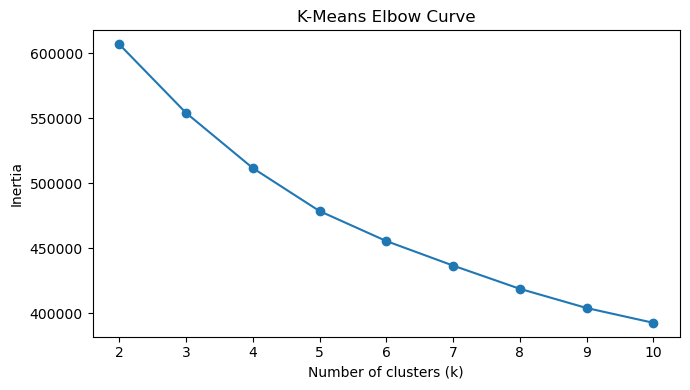

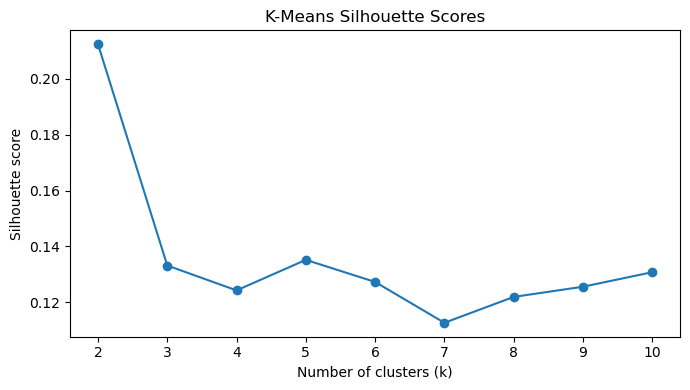

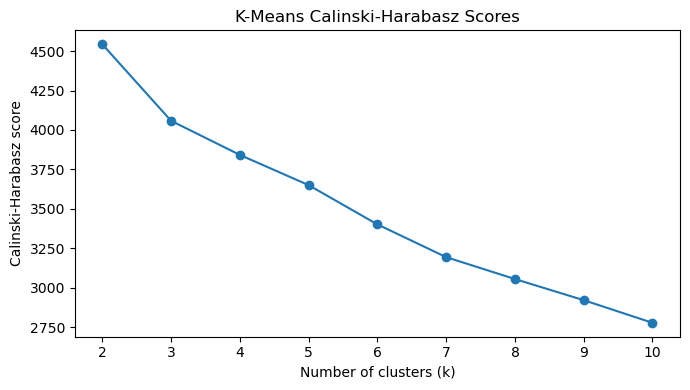

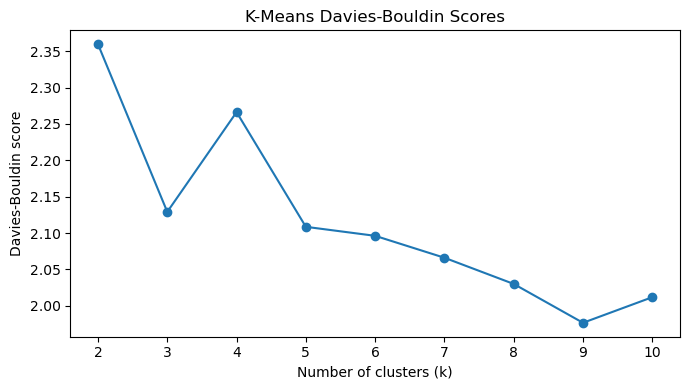

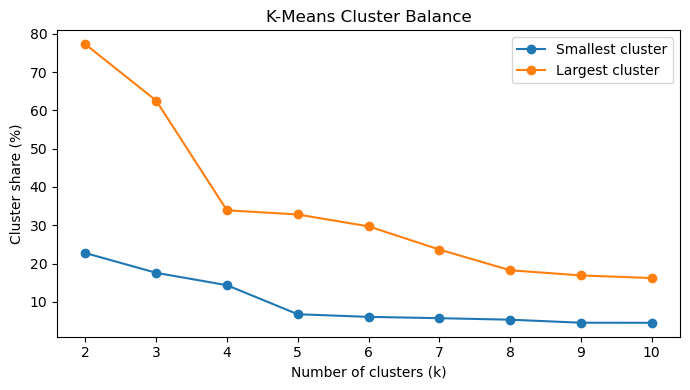

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(metrics["k"], metrics["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Curve")
plt.xticks(metrics["k"])
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(metrics["k"], metrics["silhouette_score"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("K-Means Silhouette Scores")
plt.xticks(metrics["k"])
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(metrics["k"], metrics["calinski_harabasz_score"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Calinski-Harabasz score")
plt.title("K-Means Calinski-Harabasz Scores")
plt.xticks(metrics["k"])
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(metrics["k"], metrics["davies_bouldin_score"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin score")
plt.title("K-Means Davies-Bouldin Scores")
plt.xticks(metrics["k"])
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(metrics["k"], metrics["min_cluster_percentage"], marker="o", label="Smallest cluster")
plt.plot(metrics["k"], metrics["max_cluster_percentage"], marker="o", label="Largest cluster")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Cluster share (%)")
plt.title("K-Means Cluster Balance")
plt.xticks(metrics["k"])
plt.legend()
plt.tight_layout()
plt.show()


## Initial k Choice

The initial baseline solution uses `SELECTED_K = 5`.

`k=2` has the strongest silhouette score, but it places more than three quarters of customers into one cluster, so it is too broad for useful segmentation. `k=5` is a more balanced starting point: the elbow curve still shows meaningful improvement before the gains slow down, the silhouette score is the strongest option after `k=2`, the Davies-Bouldin score improves compared with `k=4`, and the cluster sizes remain interpretable.

This does not mean `k=5` is the final clustering solution. It is a baseline choice that must be profiled and interpreted in the next phase before deciding whether the segmentation is good enough for business use.

In [6]:
SELECTED_K = 5
print(f"Selected k: {SELECTED_K}")


Selected k: 5


## Final Baseline Model

The final baseline model is fitted on the selected modelling features, not on PCA components. The saved output contains each customer and their assigned cluster.

In [7]:
final_kmeans, final_labels = fit_kmeans(X, n_clusters=SELECTED_K, random_state=42, n_init=50)

cluster_assignments = save_cluster_assignments(
    customer_ids,
    final_labels,
    "outputs/customer_clusters.csv",
)

print("Saved cluster assignments to outputs/customer_clusters.csv")
print(cluster_assignments.head())


Saved cluster assignments to outputs/customer_clusters.csv
   customer_id  cluster
0            3        3
1            4        2
2            5        3
3            7        4
4            8        4


## PCA Visualization

PCA is used only for a two-dimensional visual inspection of the clusters. K-Means is not trained on the PCA components in this baseline.

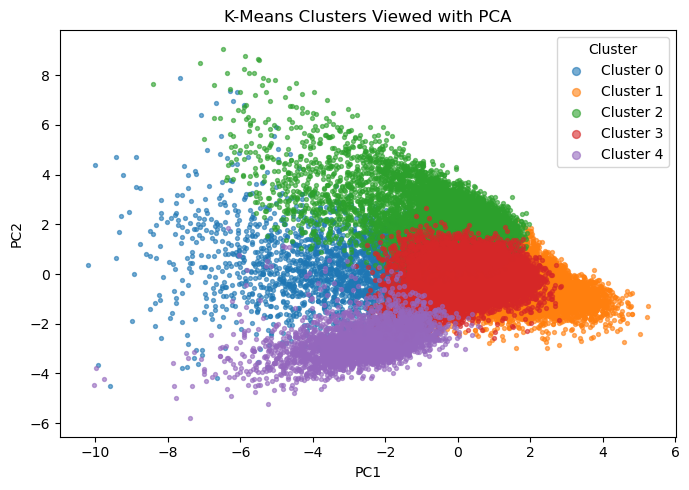

PCA explained variance ratio: [0.17950417 0.12414316]


In [8]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X)
cluster_ticks = sorted(cluster_assignments["cluster"].unique())

plt.figure(figsize=(7, 5))
for cluster in cluster_ticks:
    cluster_mask = final_labels == cluster
    plt.scatter(
        pca_components[cluster_mask, 0],
        pca_components[cluster_mask, 1],
        color=plt.cm.tab10(int(cluster)),
        label=f"Cluster {cluster}",
        s=8,
        alpha=0.6,
    )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters Viewed with PCA")
plt.legend(title="Cluster", markerscale=2, frameon=True)
plt.tight_layout()
plt.show()

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")


## t-SNE Visualization

PCA is a linear projection, so it may miss more complex cluster structure. t-SNE is added here only as another visual check of the existing K-Means clusters.

The K-Means model was not trained on t-SNE components. A sample is used because t-SNE can be slow on a large dataset.

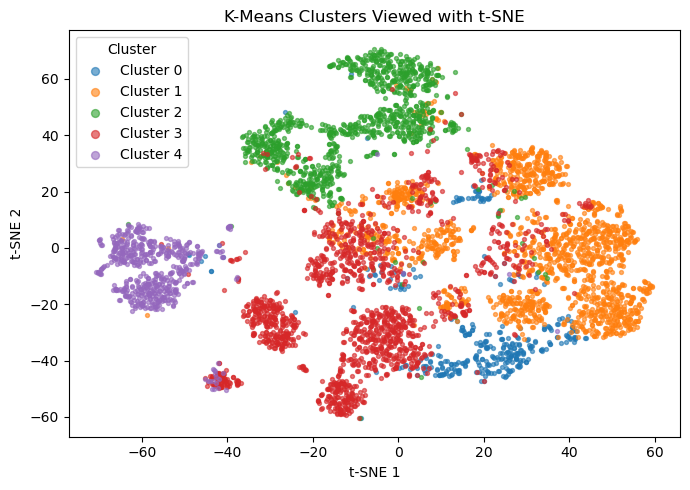

t-SNE sample rows: 5,000


In [9]:
tsne_df = create_tsne_projection(
    X,
    final_labels,
    customer_ids=customer_ids,
    sample_size=5000,
    random_state=42,
)
tsne_cluster_ticks = sorted(tsne_df["cluster"].unique())

plt.figure(figsize=(7, 5))
for cluster in tsne_cluster_ticks:
    cluster_points = tsne_df[tsne_df["cluster"] == cluster]
    plt.scatter(
        cluster_points["tsne_1"],
        cluster_points["tsne_2"],
        color=plt.cm.tab10(int(cluster)),
        label=f"Cluster {cluster}",
        s=8,
        alpha=0.6,
    )
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("K-Means Clusters Viewed with t-SNE")
plt.legend(title="Cluster", markerscale=2, frameon=True)
plt.tight_layout()
plt.show()

print(f"t-SNE sample rows: {len(tsne_df):,}")


## Final Validation

The final checks confirm that the saved cluster assignment file has one valid cluster label for every input customer.

In [10]:
saved_clusters = pd.read_csv("outputs/customer_clusters.csv")
cluster_size_table = get_cluster_summary(saved_clusters["cluster"])
row_count_matches = len(saved_clusters) == len(df)

print(f"Rows in customer_clusters.csv: {len(saved_clusters):,}")
print(f"Unique customer_id values: {saved_clusters['customer_id'].nunique():,}")
print(f"Missing cluster values: {saved_clusters['cluster'].isna().sum():,}")
print("Cluster size table:")
print(cluster_size_table.to_string(index=False))
print(f"Output row count matches input row count: {row_count_matches}")

if not row_count_matches:
    raise ValueError("Cluster output row count does not match the input row count.")

if saved_clusters["customer_id"].duplicated().sum() > 0:
    raise ValueError("Cluster output contains duplicated customer_id values.")

if saved_clusters["cluster"].isna().sum() > 0:
    raise ValueError("Cluster output contains missing cluster values.")


Rows in customer_clusters.csv: 33,038
Unique customer_id values: 33,038
Missing cluster values: 0
Cluster size table:
 cluster  count  percentage
       0   2234    6.761911
       1  10841   32.813730
       2   6687   20.240329
       3   9889   29.932199
       4   3387   10.251831
Output row count matches input row count: True


## Initial Cluster Profiling

The previous sections created the first K-Means baseline with `SELECTED_K = 5`. Now the goal is to understand what each cluster represents.

For profiling, this section uses interpretable customer features from `customer_features_info.csv`, not the scaled model input used by K-Means. The cluster names and descriptions are still provisional and should be reviewed more carefully in the next phase.

In [11]:
features_info = pd.read_csv("data/processed/customer_features_info.csv")
clusters = pd.read_csv("outputs/customer_clusters.csv")

profiling_df = clusters.merge(features_info, on="customer_id", how="left")

profiling_rows = len(profiling_df)
profiling_unique_customers = profiling_df["customer_id"].nunique()
profiling_duplicate_customers = profiling_df["customer_id"].duplicated().sum()
profiling_missing_clusters = profiling_df["cluster"].isna().sum()
preserved_all_customers = len(profiling_df) == len(clusters)

print(f"Rows in profiling dataset: {profiling_rows:,}")
print(f"Unique customer_id values: {profiling_unique_customers:,}")
print(f"Duplicated customer_id count: {profiling_duplicate_customers:,}")
print(f"Missing cluster values: {profiling_missing_clusters:,}")
print(f"All clustered customers preserved: {preserved_all_customers}")

if profiling_duplicate_customers > 0:
    raise ValueError("Profiling dataset contains duplicated customer_id values.")

if profiling_missing_clusters > 0:
    raise ValueError("Profiling dataset contains missing cluster values.")

if len(profiling_df) != len(clusters):
    raise ValueError("Profiling merge changed the number of customer rows.")


Rows in profiling dataset: 33,038
Unique customer_id values: 33,038
Duplicated customer_id count: 0
Missing cluster values: 0
All clustered customers preserved: True


### Profile Summary

The profile table compares each cluster using readable customer-level features. Means and medians are both included because some customer behavior variables can be skewed.

In [12]:
profile_columns = [
    "age",
    "customer_tenure",
    "total_lifetime_spend",
    "lifetime_total_distinct_products",
    "percentage_of_products_bought_promotion",
    "number_complaints",
    "distinct_stores_visited",
    "has_loyalty_card",
    "total_children_home",
    "has_children",
]
profile_columns = [column for column in profile_columns if column in profiling_df.columns]

cluster_profile = create_cluster_profile(
    profiling_df,
    cluster_column="cluster",
    columns=profile_columns,
)
cluster_profile.to_csv("outputs/kmeans_cluster_profile_summary.csv", index=False)

print(f"Profile columns used: {profile_columns}")
print("Saved profile summary to outputs/kmeans_cluster_profile_summary.csv")
cluster_profile


Profile columns used: ['age', 'customer_tenure', 'total_lifetime_spend', 'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion', 'number_complaints', 'distinct_stores_visited', 'has_loyalty_card', 'total_children_home', 'has_children']
Saved profile summary to outputs/kmeans_cluster_profile_summary.csv


,cluster,age_mean,age_median,customer_tenure_mean,customer_tenure_median,total_lifetime_spend_mean,total_lifetime_spend_median,lifetime_total_distinct_products_mean,lifetime_total_distinct_products_median,percentage_of_products_bought_promotion_mean,...,number_complaints_mean,number_complaints_median,distinct_stores_visited_mean,distinct_stores_visited_median,has_loyalty_card_mean,has_loyalty_card_median,total_children_home_mean,total_children_home_median,has_children_mean,has_children_median
0,0,62.176364,65.0,14.649508,15.0,10809.504029,9862.0,173.333483,161.0,0.392418,...,0.977574,1.0,3.668324,4.0,0.672337,1.0,1.994053,2.0,0.866159,1.0
1,1,62.900398,64.0,16.264920,17.0,36521.748270,33599.0,238.076192,230.0,0.255912,...,0.824857,1.0,3.187028,3.0,0.710912,1.0,2.969047,2.0,0.931372,1.0
2,2,60.742401,61.0,13.346643,14.0,16669.059070,16643.0,102.597278,98.0,0.129039,...,0.667480,1.0,3.391344,3.0,0.582174,1.0,1.897252,2.0,0.952894,1.0
3,3,49.851152,44.0,11.609465,12.0,17163.872990,15616.0,91.752553,69.0,0.519626,...,1.171039,1.0,3.457038,3.0,0.529477,1.0,1.546504,2.0,0.801497,1.0
4,4,59.138955,59.0,11.549749,12.0,23296.661352,23207.0,105.763803,100.0,0.259955,...,1.059391,1.0,1.493893,1.0,0.470623,0.0,0.577282,0.0,0.436670,0.0


### Spending Share Profile

This table checks which product groups have the highest average spending share inside each cluster.

In [13]:
share_columns = [column for column in profiling_df.columns if column.startswith("share_")]

cluster_spending_shares = profiling_df.groupby("cluster")[share_columns].mean().reset_index()
cluster_spending_shares.to_csv("outputs/kmeans_cluster_spending_shares.csv", index=False)

print(f"Spending share columns used: {share_columns}")
print("Saved spending share profile to outputs/kmeans_cluster_spending_shares.csv")
cluster_spending_shares


Spending share columns used: ['share_groceries', 'share_electronics', 'share_vegetables', 'share_nonalcohol_drinks', 'share_alcohol_drinks', 'share_meat', 'share_fish', 'share_hygiene', 'share_videogames', 'share_petfood']
Saved spending share profile to outputs/kmeans_cluster_spending_shares.csv


,cluster,share_groceries,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood
0,0,0.385542,0.149699,0.054550,0.044156,0.054202,0.098056,0.074559,0.079993,0.027775,0.042853
1,1,0.751817,0.085894,0.019183,0.017129,0.022784,0.030981,0.027777,0.028468,0.009177,0.011324
2,2,0.599394,0.095430,0.118946,0.034027,0.020332,0.008114,0.007150,0.087119,0.012725,0.022346
3,3,0.738744,0.059957,0.025169,0.015640,0.030448,0.043438,0.028222,0.031456,0.012452,0.019402
4,4,0.347655,0.401118,0.009753,0.025153,0.050966,0.041024,0.038341,0.012776,0.069746,0.014030


### Profile Plots

These simple plots focus on spend level, promotion sensitivity, and loyalty rate because they are useful first checks for customer segmentation.

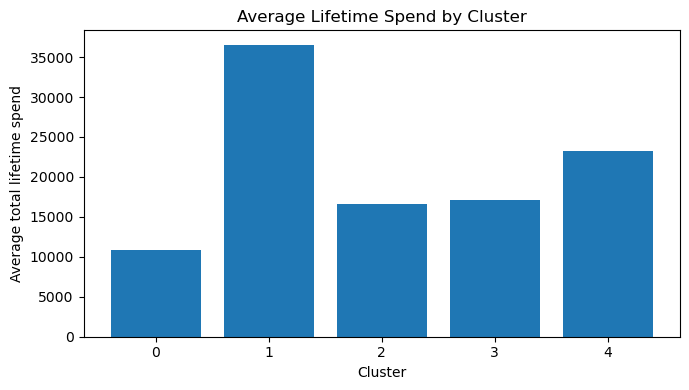

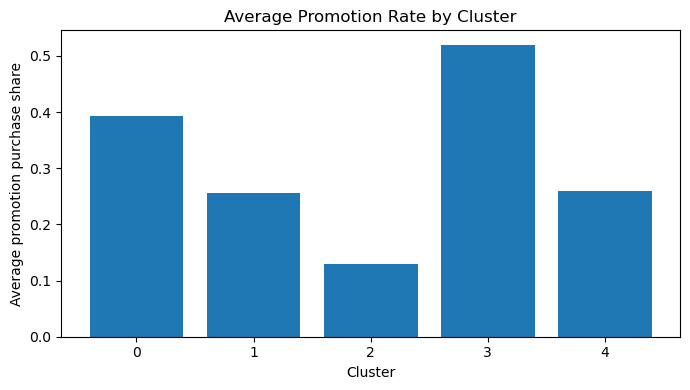

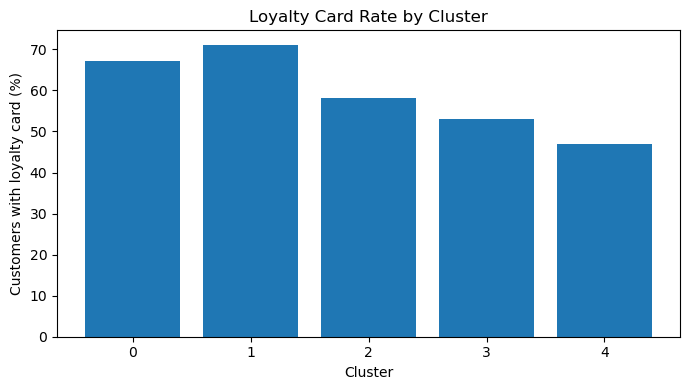

In [14]:
spend_by_cluster = profiling_df.groupby("cluster")["total_lifetime_spend"].mean()
promotion_by_cluster = profiling_df.groupby("cluster")["percentage_of_products_bought_promotion"].mean()
loyalty_by_cluster = profiling_df.groupby("cluster")["has_loyalty_card"].mean() * 100

plt.figure(figsize=(7, 4))
plt.bar(spend_by_cluster.index.astype(str), spend_by_cluster.values)
plt.xlabel("Cluster")
plt.ylabel("Average total lifetime spend")
plt.title("Average Lifetime Spend by Cluster")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(promotion_by_cluster.index.astype(str), promotion_by_cluster.values)
plt.xlabel("Cluster")
plt.ylabel("Average promotion purchase share")
plt.title("Average Promotion Rate by Cluster")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(loyalty_by_cluster.index.astype(str), loyalty_by_cluster.values)
plt.xlabel("Cluster")
plt.ylabel("Customers with loyalty card (%)")
plt.title("Loyalty Card Rate by Cluster")
plt.tight_layout()
plt.show()


### Provisional Interpretation

These descriptions are early profiling notes, not final segment names. The next phase should validate whether these groups are stable, useful, and meaningful for business decisions.

**Cluster 0**

- Appears to have older customers with below-average lifetime spend.
- Shows above-average promotion usage and the highest average number of stores visited.
- Seems less grocery-dominated than most clusters, with more spread across electronics and meat.

**Cluster 1**

- Appears to be the highest-value cluster, with the highest average lifetime spend and most distinct products.
- Shows the highest average tenure and the highest loyalty-card rate.
- Seems strongly grocery-focused and has the highest average number of children at home.

**Cluster 2**

- Shows lower-than-average lifetime spend and a low promotion purchase share.
- Appears to have many customers with children, but fewer distinct products than clusters 0 and 1.
- Seems mainly grocery-focused, with vegetables also more visible than in several other clusters.

**Cluster 3**

- Appears to contain younger customers with shorter tenure than the overall average.
- Shows the highest promotion purchase share and the highest average complaint count.
- Seems grocery-heavy, but with lower loyalty-card usage than clusters 0, 1, and 2.

**Cluster 4**

- Appears to have fewer children at home and the lowest loyalty-card rate.
- Shows the lowest average number of stores visited.
- Seems more focused on electronics than the other clusters, with groceries still important but less dominant.